# LM Lab: Neural models for word vector representation

- Alejandro Silva
- Fernando Baña
- Daniel Prieto

In [5]:
import os

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Disable TensorFlow logging
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from tqdm import tqdm
from utils import *

FILE_PATH = "data/eng_news_2024_30k_sentences.txt"

## Data Cleaning and Preprocessing

We are given the txt file in the following format:

- Each line contains a sentence.
- Each sentence is a sequence of words separated by spaces.
- All sentences end with a period ('.').


In [3]:
with open(FILE_PATH, "r") as f:
    # Read the file and store only the non-empty lines in a list
    text_data = [line.strip() for line in f if line.strip()]

print(f"Loaded {len(text_data)} sentences")
print(f"First 5 sentences:")
for i in range(5):
    print(f"{i+1}: {text_data[i]}")

Loaded 30000 sentences
First 5 sentences:
1: $10-$15 suggested donation goes to Falmouth Land Trust.
2: $20,000: Lower Adirondack Pride Festival, June 1 in City Park, Glens Falls.
3: $239.4 billion (32nd), comparable to Hungary.
4: $35, $75 family of three or more.
5: £1,200: Provision of funding for Year 1 & Year 2 children to attend Enchantica Christmas Show / Grove Road Community Primary School.


## Word Embedding Models

In this section we will implement the required models. The models are based on the **prediction of words given their context**. The models will have the following characteristics:

- They will take as input the context, n words preciding/following the target word.
- They will try to predict the target word given the context.

Therefore we have:
- Input $\rightarrow$ Context (n words)
- Output $\rightarrow$ Target word

### Tokenization and Vocabulary Building

To implement the word embedding models, we first need to preprocess the text data. This involves tokenizing the sentences and building a vocabulary of unique words. For this task we will use the TextVectorizer from the Keras library, and use it to convert the sentences into sequences of integersmm, where each integer represents a unique word in the vocabulary.

We will use a limited vocabulary size to keep the models to train.

In [15]:
VOCAB_SIZE = 10000

vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    standardize="lower_and_strip_punctuation",
    pad_to_max_tokens=True,
)

# Now we can adapt the vectorizer to our text data
vectorizer.adapt(text_data)

# Get the vocabulary and create mappings from words to indices
vocab = vectorizer.get_vocabulary()
print(f"Vocabulary size: {len(vocab)}")
word_to_index = {word: index for index, word in enumerate(vocab)}
print(word_to_index)
index_to_word = {index: word for index, word in enumerate(vocab)}

Vocabulary size: 10000
{'': 0, '[UNK]': 1, np.str_('the'): 2, np.str_('to'): 3, np.str_('and'): 4, np.str_('of'): 5, np.str_('a'): 6, np.str_('in'): 7, np.str_('for'): 8, np.str_('on'): 9, np.str_('that'): 10, np.str_('is'): 11, np.str_('with'): 12, np.str_('was'): 13, np.str_('it'): 14, np.str_('as'): 15, np.str_('at'): 16, np.str_('be'): 17, np.str_('he'): 18, np.str_('from'): 19, np.str_('has'): 20, np.str_('this'): 21, np.str_('have'): 22, np.str_('said'): 23, np.str_('are'): 24, np.str_('by'): 25, np.str_('an'): 26, np.str_('i'): 27, np.str_('his'): 28, np.str_('will'): 29, np.str_('but'): 30, np.str_('their'): 31, np.str_('you'): 32, np.str_('not'): 33, np.str_('they'): 34, np.str_('we'): 35, np.str_('its'): 36, np.str_('been'): 37, np.str_('who'): 38, np.str_('her'): 39, np.str_('she'): 40, np.str_('were'): 41, np.str_('or'): 42, np.str_('also'): 43, np.str_('after'): 44, np.str_('had'): 45, np.str_('one'): 46, np.str_('can'): 47, np.str_('up'): 48, np.str_('more'): 49, np.str_(

### Generating Training Data for the Models

Now that we have the vectorizer adapted to out data, we can start generating the training data for the models.

In [17]:
WINDOW_SIZE = 2  # Number of words to the left and right of the target word
CONTEXT_SIZE = 2 * WINDOW_SIZE  # Total number of context words for each target word

X_train = []
y_train = []

# First transform the sentences into sequences of integers
sequences = vectorizer(text_data).numpy()

print(f"First 3 sequences:")
for i in range(3):
    print(f"{i+1}: {sequences[i]}")

for seq in tqdm(sequences):
    # Remove padding (0s) from the sequence
    seq = [token for token in seq if token != 0]

    # We need at least CONTEXT_SIZE + 1 to form the valid contexts windows and targets

    if len(seq) < CONTEXT_SIZE + 1:
        continue

    for i in range(WINDOW_SIZE, len(seq) - WINDOW_SIZE):
        target = seq[i]
        context = seq[i - WINDOW_SIZE : i] + seq[i + 1 : i + 1 + WINDOW_SIZE]
        X_train.append(context)
        y_train.append(target)

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"Number of training samples: {len(X_train)}")
print(f"Sample training data (context -> target):")
print(f"X: {X_train[0]} ({[index_to_word[idx] for idx in X_train[0]]})")
print(f"y: {y_train[0]} ({index_to_word[y_train[0]]})")

First 3 sequences:
1: [8437 1636 5602  822    3    1  754  653    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
2: [4675  855    1 3153  940  422  423    7  148  426    1 2958    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
3: [   1  379    1 7306    3    1    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


100%|██████████| 30000/30000 [00:00<00:00, 67183.07it/s]


Number of training samples: 470316
Sample training data (context -> target):
X: [8437 1636  822    3] ([np.str_('1015'), np.str_('suggested'), np.str_('goes'), np.str_('to')])
y: 5602 (donation)


### Embedding Model Architecture

In [ ]:
EMBEDDING_DIMS = 100
EPOCHS = 10
BATCH_SIZE = 128

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models/word_embedding_model.keras", save_best_only=True, monitor="loss"
    )
]

inputs = keras.Input(shape=(CONTEXT_SIZE,), dtype="int32")
embedding_layer = layers.Embedding(
    input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIMS, input_length=CONTEXT_SIZE, name="word_embeddings"
)
embeddings = embedding_layer(inputs)
flattened = layers.GlobalAveragePooling1D()(embeddings)
outputs = layers.Dense(VOCAB_SIZE, activation="softmax")(flattened)

model = keras.Model(inputs=inputs, outputs=outputs)
optimizer = keras.optimizers.Adam()
model.compile(
    optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
model.summary()

/Users/daniprieto/miniconda3/envs/dl/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 4, 100)         │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10000)          │     1,010,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,010,000 (7.67 MB)

 Trainable params: 2,010,000 (7.67 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    validation_split=0.1,
)

Epoch 1/10
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.1124 - loss: 6.6247 - val_accuracy: 0.1295 - val_loss: 6.2433
Epoch 2/10
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - accuracy: 0.1521 - loss: 6.0286 - val_accuracy: 0.1601 - val_loss: 5.9549
Epoch 3/10
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - accuracy: 0.1802 - loss: 5.7359 - val_accuracy: 0.1687 - val_loss: 5.8191
Epoch 4/10
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - accuracy: 0.1950 - loss: 5.5360 - val_accuracy: 0.1721 - val_loss: 5.7417
Epoch 5/10
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - accuracy: 0.2050 - loss: 5.3766 - val_accuracy: 0.1754 - val_loss: 5.6951
Epoch 6/10
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - accuracy: 0.2130 - loss: 5.2409 - val_accuracy: 0.1748 - val_loss: 5.6641
Epoch 7/10
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - accuracy: 0.2191 - loss: 5.1216 - val_accuracy: 0.1750 - val_loss: 5.6472
Epoch 8/10
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - accuracy: 0.2242 -

In [ ]:
# extract the learned weights from the Embedding layer
embedding_layer = model.get_layer("word_embeddings")
trained_embeddings = embedding_layer.get_weights()[0]

# Save as a numpy array so it can be used later
np.save(
    f"embeddings/embeddings_D{EMBEDDING_DIMS}_c{CONTEXT_SIZE}_v{VOCAB_SIZE}.npy",
    trained_embeddings,
)

## Analysis of the Results

In order to analyze the results from the different models we will use the following metrics:

- **Cosine Similarity**: To compare the similarity between the given target words and the results obtained from the models.
- **Visualization using t-SNE**: To visualize the word embeddings in a 2D space and observe how words are grouped together 

### Semantic Cosine Similarity

In [22]:
def get_cosine_similarity(vec1, vec2):
    """Calculate the cosine similarity between two vectors."""
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0.0
    return dot_product / (norm_vec1 * norm_vec2)


def get_top_k_similar_words(target_word, embeddings, word_index, vocab, k=10):
    """Get the top k most similar words to the given word based on cosine similarity."""
    if target_word not in word_to_index:
        print(f"Word '{target_word}' not found in vocabulary.")
        return []

    target_idx = word_to_index[target_word]
    target_vector = embeddings[target_idx]

    similarities = []
    for word, idx in word_index.items():
        if word == target_word or word == "":  # Skip self and padding
            continue
        sim = get_cosine_similarity(target_vector, embeddings[idx])
        similarities.append((word, sim))

    # Sort by descending similarity and return top K
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:k]


# Load the target words

with open("materials/target_words.txt", "r") as f:
    target_words = [w.strip() for w in f if w.strip() in word_to_index]

print("Top 10 similar words per target word:\n")
for word in target_words:
    top_10 = get_top_k_similar_words(
        word, trained_embeddings, word_to_index, vocab, k=10
    )
    print(f"Target: '{word}'")
    for word, sim in top_10:
        print(f"  - {word}: {sim:.4f}")
    print()

Top 10 similar words per target word:

Target: 'everyone'
  - everybody: 0.7751
  - someone: 0.7666
  - me: 0.7284
  - god: 0.7246
  - somebody: 0.7151
  - anything: 0.6923
  - everything: 0.6922
  - anyone: 0.6816
  - something: 0.6533
  - spoken: 0.6336

Target: 'music'
  - color: 0.5508
  - performances: 0.5491
  - soccer: 0.5138
  - food: 0.5054
  - parks: 0.4927
  - too”: 0.4855
  - arts: 0.4802
  - art: 0.4789
  - healing: 0.4692
  - dressing: 0.4632

Target: 'running'
  - breaking: 0.5926
  - professionalism: 0.5799
  - sweden: 0.5579
  - flying: 0.5579
  - knee: 0.5553
  - fork: 0.5496
  - returning: 0.5468
  - tears: 0.5441
  - unpopular: 0.5316
  - thrown: 0.5273

Target: 'worse'
  - better: 0.6999
  - faster: 0.6774
  - slower: 0.6752
  - heavier: 0.6529
  - less: 0.6480
  - pregnant: 0.6328
  - harder: 0.6320
  - cheaper: 0.6154
  - more: 0.6151
  - bigger: 0.6079

Target: 'friday'
  - monday: 0.9063
  - tuesday: 0.8749
  - wednesday: 0.8416
  - thursday: 0.8312
  - sunday:

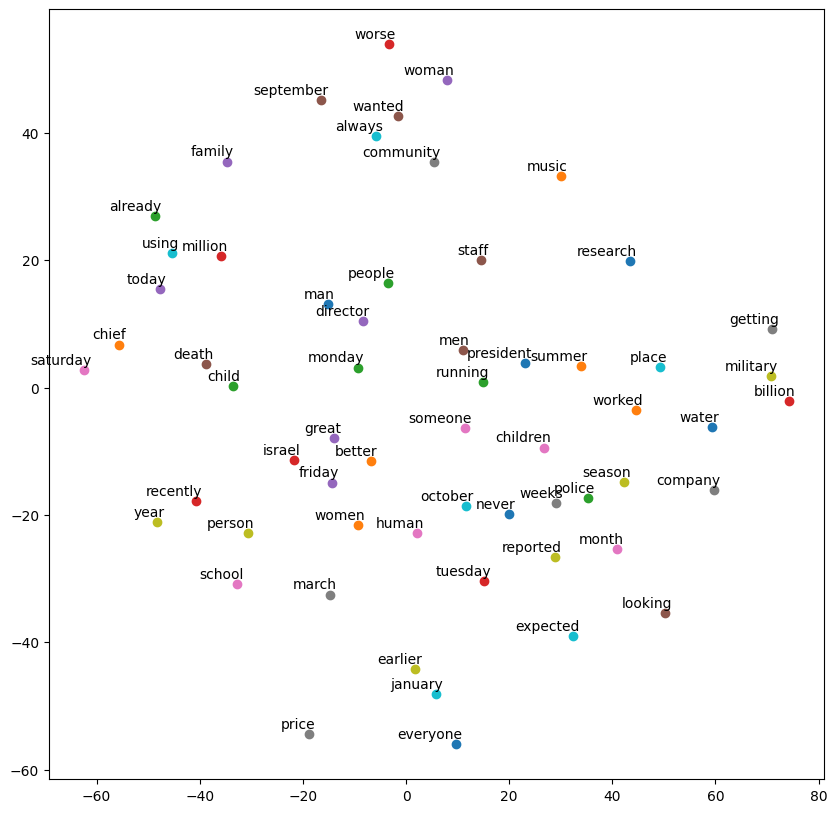

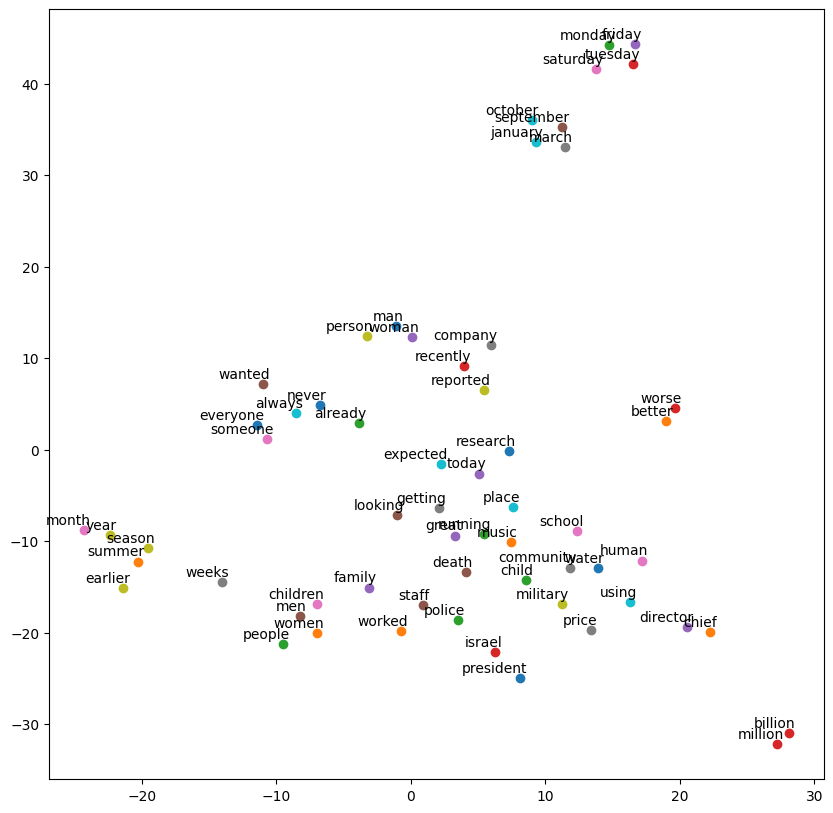

In [23]:
# 1. Visualization BEFORE training (Initialize random embeddings of the same shape)
untrained_embeddings = np.random.randn(*trained_embeddings.shape)
visualize_tsne_embeddings(target_words, untrained_embeddings, word_to_index)

# 2. Visualization AFTER training
visualize_tsne_embeddings(target_words, trained_embeddings, word_to_index)

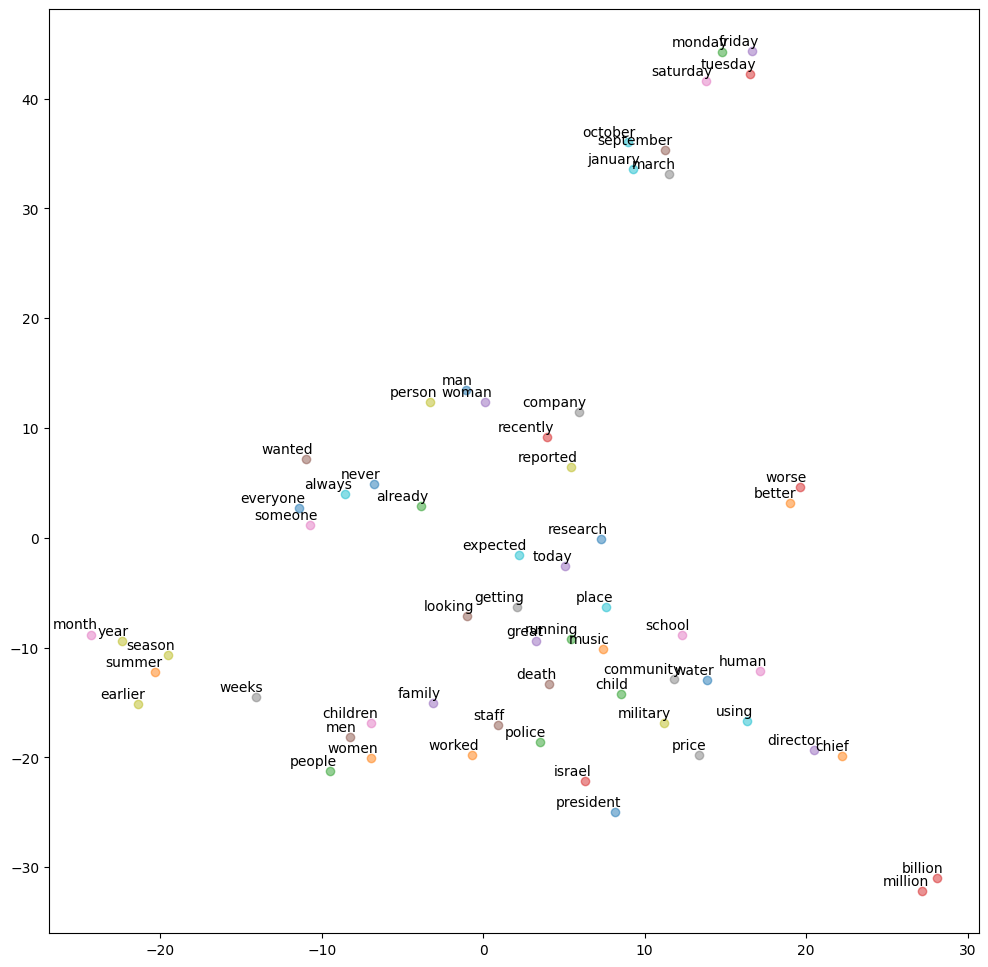

In [24]:
visualize_all_tsne_embeddings(trained_embeddings, word_to_index, target_words)